<a href="https://colab.research.google.com/github/rmmandrade/ml2526/blob/main/Grupo57_vf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz, distance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, make_scorer, r2_score, mean_absolute_error
#from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor

# Data Preprocessing

#### Data Quality Assessment and Initial Observations

In [ ]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Let's perform an initial analysis of the train dataset.

In [ ]:
df=pd.read_csv("train.csv")
display(df)
og_df = df.copy()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


There's a total of 14 columns, with one of them being a candidate to be a unique identifier for each row (**carID**), leaving us 13 features to work with.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB



Datatypes seem to be A-OK, thus we are left with 4 categorical features:

**Brand, model, transmission and fuelType**

And 10 numeric features:

**cardID, year, price, mileage, tax, mpg, engineSize, paintQuality%, previousOwners and hasDamage**


In [ ]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


#### Preprocessing **cardID**

Now for us to be able to use **carID** as a true unique identifier we must first make sure there are no duplicates:

In [ ]:
df["carID"].duplicated().any()

np.False_

Since there are no duplicates we can now define **carID** as a true unique identifier.

In [ ]:
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


##### Let's assess feature values and counts and see if there's any work to be done here. Let's start with **Brand**

#### Preprocessing **Brand**

In [ ]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

##### Several values for the same brand although with some missing letters (e.g. 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' could be considered as all being the same value: AUDI) and some nans.

In [ ]:
df["Brand"].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [ ]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0



~1500 NaNs
To fix incorrect entries, we must define a method to be able to treat these values for **Brand** and have the correct single unique brand name.

To fix the inconsistent and misspelled values for Brand, we’ll define a function that uses fuzzy string matching to map incorrect entries to their correct versions.

The first helper function we’ll define is **HELPER_marca_correta()**, responsible for evaluating each brand value individually and correcting it if necessary. It first checks whether the brand value is valid (i.e., not NaN or empty) and then converts it to lowercase for comparison.

Using fuzzywuzzy **process.extractOne()** (which uses Levenshtein distance or a tokenizer), we compare the given brand to the dictionary of valid brands (**valid_brands**) and returns the closest match, along with a similarity score.

If the similarity score exceeds a defined threshold, the brand value is replaced by the correct brand name. Otherwise, it remains unchanged. The second function, **fuzzy_marcas()**, applies this logic to the entire dataset. It first defines a list of valid brands — in this case: VW, Toyota, Audi, Ford, BMW, Opel, Skoda, Mercedes, and Hyundai.

These are converted into a lowercase dictionary for matching, where each key-value pair ensures the final brand name retains its original capitalization.

Finally, **fuzzy_marcas()** applies **HELPER_marca_correta()** to every value in Brand, replacing incorrect or misspelled records with their correct forms. The **threshold parameter (threshold=50)** controls how strict the matching is. A lower threshold (e.g. 50) allows more aggressive corrections, while a higher one (e.g. 80) ensures only very similar strings are replaced.

This process effectively normalizes **Brand**, e.g. consolidating entries such as 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' into their correct standardized name, 'Audi'.


In [ ]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )

    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [ ]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

Thus, the treatment via **HELPER_marca_correta()** was successfull, and we are now left with 9 true brand names and NaN's.

In [ ]:
df["Brand"].value_counts()

Brand
Ford        16063
Mercedes    11674
VW          10385
Opel         9352
BMW          7392
Audi         7325
Toyota       4622
Skoda        4303
Hyundai      3336
Name: count, dtype: int64

#### Preprocessing **model**

In [ ]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [ ]:
len(df["model"].unique())

736

In [ ]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])


model
 Tucson      821
 I10         671
 I30         352
 I20         307
 Kona        213
 Ioniq       185
 Santa Fe    135
 IX20        129
 I40          78
 IX35         74
 I800         72
 i10          20
 Tucso        18
 TUCSON       17
 tucson       16
 I1           15
Tucson        15
I10           13
 I3            9
 Santa F       8
 i30           8
 Ioni          7
 i20           7
 Getz          6
Ioniq          6
Kona           6
I20            5
I30            5
 I2            4
 SANTA FE      4
 I80           3
 IX2           3
 ix20          3
 kona          3
 santa fe      3
Santa Fe       3
 IONIQ         2
 KONA          2
 Kon           2
 ix35          2
IX20           2
IX35           2
 Accent        1
 KON           1
 TUCSO         1
 Terracan      1
 Veloste       1
 i40           1
 ioniq         1
I40            1
IONIQ          1
Tucso          1
Name: count, dtype: int64

In [ ]:
"""Optained through meticulous ChatGPT prompt engineering"""
valid_models = {
    "Audi": [
        "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
        "Q2", "Q3", "Q5", "Q7", "Q8",
        "TT", "T", "R8",
        "S3", "S4", "S5", "S8",
        "RS3", "RS4", "RS5", "RS6",
        "SQ5", "SQ7"
    ],

    "Ford": [
        "FOCUS", "FIESTA", "MONDEO", "KA", "KA+", "FUSION",
        "KUGA", "ECOSPORT", "EDGE", "PUMA",
        "CMAX", "BMAX", "SMAX", "GALAXY",
        "GRANDCMAX", "TOURNEOCONNECT", "GRANDTOURNEOCONNECT", "TOURNEOCUSTOM",
        "MUSTANG", "RANGER", "ESCORT", "STREETKA"
    ],

    "Mercedes": [
        "ACLASS", "BCLASS", "CCLASS", "ECLASS", "SCLASS",
        "GLA", "GLB", "GLC", "GLE", "GLS", "GCLASS", "GLCLASS", "MCLASS",
        "CLA", "CLS", "SL", "SLK", "CLK",
        "VCLASS", "XCLASS", "CLC"
    ],

    "VW": [
        "GOLF", "POLO", "PASSAT", "JETTA", "ARTEON", "SCIROCCO", "BEETLE",
        "UP", "GOL", "FOX",
        "TIGUAN", "TIGUANALLSPACE", "TROC", "TCROSS", "TOUAREG",
        "TOURAN", "SHARAN", "CADDY", "CADDYMAXI", "CADDYMAXILIFE",
        "CARAVELLE", "CALIFORNIA", "SHUTTLE",
        "AMAROK", "GOLFSV", "CC"
    ],

    "Opel": [
        "CORSA", "ASTRA", "INSIGNIA", "VECTRA",
        "MOKKA", "MOKKAX", "CROSSLAND", "CROSSLANDX",
        "GRANDLAND", "GRANDLANDX", "ANTARA",
        "ZAFIRA", "ZAFIRATOURER", "MERIVA", "COMBOLIFE", "VIVARO",
        "ADAM", "AGILA", "VIVA",
        "TIGRA", "GTC", "CASCADA", "AMPERA"
    ],

    "BMW": [
        "1SERIES", "2SERIES", "3SERIES", "4SERIES",
        "5SERIES", "6SERIES", "7SERIES", "8SERIES",
        "X1", "X2", "X3", "X4", "X5", "X6", "X7",
        "M2", "M3", "M4", "M5", "M6",
        "Z3", "Z4",
        "I3", "I4", "I8"
    ],

    "Toyota": [
        "YARIS", "AYGO", "AURIS", "COROLLA", "AVENSIS", "CAMRY", "PRIUS",
        "CHR", "RAV4", "LANDCRUISER", "URBANCRUISER",
        "VERSO", "VERSOS", "PROACEVERSO",
        "HILUX", "GT86", "SUPRA", "IQ"
    ],

    "Skoda": [
        "FABIA", "OCTAVIA", "SUPERB", "RAPID", "SCALA",
        "KODIAQ", "KAROQ", "KAMIQ", "YETI", "YETIOUTDOOR",
        "CITIGO", "ROOMSTER"
    ],

    "Hyundai": [
        "I10", "I20", "I30", "I40", "ACCENT", "GETZ",
        "KONA", "TUCSON", "SANTAFE", "IX20", "IX35",
        "I800", "IONIQ", "VELOSTER", "TERRACAN"
    ]
}


We are now left with a dictionary with valid brand names and their corresponding valid model names. Let's perform a similar treatment to the one applied to **Brand** to standardize entries for **model**.

In [ ]:
def HELPER_normalize_models(df):
    df = df.copy()

    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df

def HELPER_hybrid_scorer(a, b, **kwargs):
    #hibrido entre o método tokenizer e o levenshtein
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100

def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model

    # Skip unknown brands
    if brand not in valid_models_dict:
        return model

    valid_list = valid_models_dict[brand]

    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)

    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df

In [ ]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [ ]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [ ]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [ ]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        26
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          26
Name: model, dtype: int64


To treat the records which have valid **model** names but 'None' has its **Brand** value, we can define a function to infer the **Brand** value via the corresponding measure of central tendency, in this case, the mode.

E.g. the case where a record has 'TROC' as a **model** value and 'None' as a **Brand** value, **inferir_marca_com_modelo(df, valid_moedels_dict)** will search in the dictionary **valid_models_dict** for the **models** and its corresponding **Brand** and fill in with the mode of that specific **model** (i.e. its true brand name), thus resulting in the imputation of 'VW'.

In [ ]:
def inferir_marca_com_modelo(df, valid_models_dict):
    df = df.copy()

 # Build a mapping of models → their most frequent (mode) brand in the dataset
    model_to_brand = (
        df[df["Brand"].notna()]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
        .to_dict()
    )

    df["Brand"] = df.apply(
    lambda row: (
        row["Brand"]
        if pd.notna(row["Brand"])
        else model_to_brand.get(row["model"], None)
    ),
    axis=1
    )

    return df


In [ ]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,TROC,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,GOLF,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [ ]:
df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
45338,None,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
16342,None,None,2017.0,8600,MANUAL,28820.0,Diesel,0.0,74.4,1.5,NaN,0.0,0.0
38054,None,CLSCLASS,2018.0,31026,Automatic,17663.0,Diesel,145.0,48.7,2.9,94.0,0.0,0.0
12064,None,None,2018.0,21300,Automatic,11258.0,NaN,145.0,64.2,2.0,60.0,3.0,0.0
44351,None,None,2013.0,12990,Automatic,43000.0,Diesel,145.0,54.3,2.1,78.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68226,None,None,2017.0,10491,Manual,22211.0,Petrol,150.0,60.1,1.2,82.0,0.0,0.0
4703,None,None,2019.0,51990,Automatic,10.0,Petrol,NaN,30.4,2.9,54.0,1.0,0.0
41846,None,GLCCLASS,2019.0,31400,Semi-Auto,7670.0,Diesel,145.0,44.8,2.0,60.0,3.0,0.0


In [ ]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [ ]:
df

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,YARIS,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2SERIES,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,AYGO,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


#### Preprocessing **year**

In [ ]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [ ]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [ ]:
old_cars = df[df["year"] < 2000][["Brand", "model", "year"]]
display(old_cars)
#os carros de 1970 nem existiam em 1970

,Brand,model,year
carID,,,
25881,Ford,ESCORT,1996.0
3908,Audi,A3,1998.0
62732,Opel,ZAFIRA,1970.0
13422,BMW,Z3,1999.0
36128,Mercedes,SLK,1998.0
51800,Toyota,YARIS,1999.0
34918,Mercedes,SCLASS,1997.0
52914,Toyota,LANDCRUISER,1998.0
35769,Mercedes,MCLASS,1970.0


In [ ]:
def limpar_anos(df):
    df = df.copy()

    df["year"] = np.round(df["year"]).astype("float")
    df.loc[(df["year"] < 1980) | (df["year"] > 2020),"year"] = np.nan
    df["year"] = df["year"].astype("Int64")
    return df

In [ ]:
df = limpar_anos(df)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [ ]:
df["year"].unique()

<IntegerArray>
[2016, 2019, 2018, 2014, 2017, 2020, 2013, <NA>, 2015, 2011, 2012, 2003, 2009,
 2007, 2005, 2004, 2010, 2008, 2006, 2001, 2000, 2002, 1996, 1998, 1999, 1997]
Length: 26, dtype: Int64

#### Preprocessing **price**

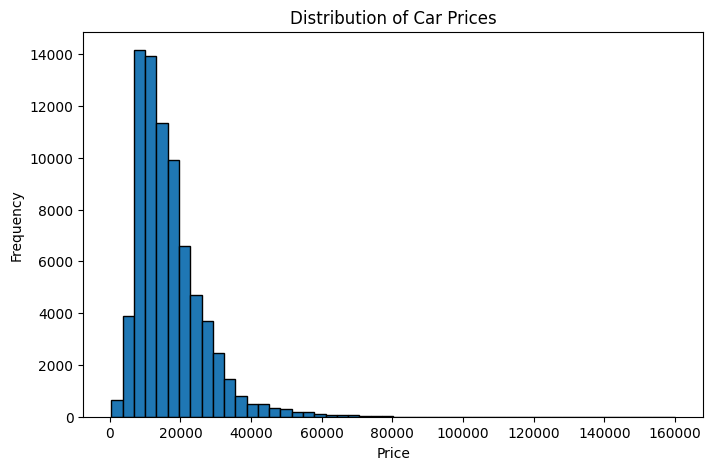

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["price"].describe()

count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

In [ ]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)
#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003,450
19562,Ford,FOCUS,2003,495
23427,Ford,FOCUS,2003,495
61005,Opel,CORSA,2002,495
55950,Opel,CORSA,2003,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003,450
19562,Ford,FOCUS,2003,495
23427,Ford,FOCUS,2003,495
61005,Opel,CORSA,2002,495
55950,Opel,CORSA,2003,590


In [ ]:
def preco_no_fim(df):
    df = df.copy()

    df = df[[col for col in df.columns if col != "price"] + ["price"]]
    return df

#### Preprocessing **transmission**

In [ ]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [ ]:
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,2015,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,2020,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,2019,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [ ]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [ ]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm

    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

In [ ]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,2015,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,2020,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,2019,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [ ]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

#### Preprocessing **mileage**

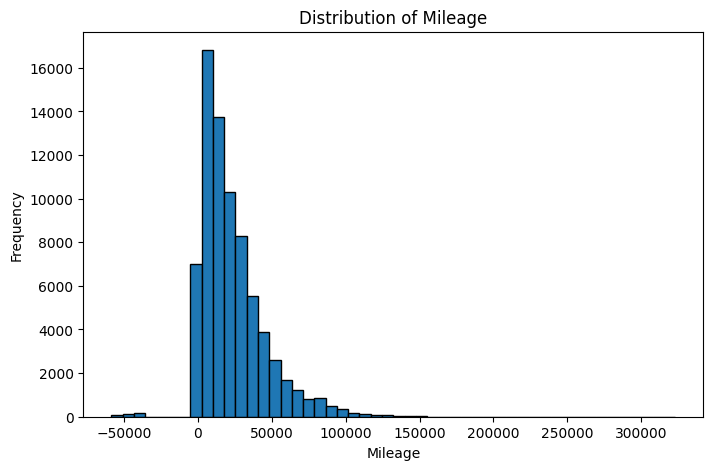

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,2017,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,2017,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,2016,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,2019,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,2019,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,2017,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,2019,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


In [ ]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,2020,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,2019,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2018,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,2019,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,2017,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2018,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,2020,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,2015,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [ ]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

In [ ]:
df=impossible_to_nan(df, "mileage")
df.loc[70615]

Brand                 VW
model             TIGUAN
year                2020
price              25000
transmission      MANUAL
mileage              NaN
fuelType          Petrol
tax                145.0
mpg                 38.2
engineSize           1.5
paintQuality%       89.0
previousOwners       3.0
hasDamage            0.0
Name: 70615, dtype: object

In [ ]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


In [ ]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,2017,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,2017,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,2016,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,2019,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,2019,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,2016,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,2019,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


#### Preprocessing **fuelType**

In [ ]:
df["fuelType"].unique()

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

In [ ]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,2017,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,2017,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,2017,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,2017,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,2016,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [ ]:
df["fuelType"].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

In [ ]:
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [ ]:
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel

    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df

In [ ]:
df=fuzzy_fuel(df)
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [ ]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,2017,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,2017,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,2017,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,2017,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,2016,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [ ]:
df["fuelType"].value_counts()

fuelType
PETROL      41181
DIESEL      30885
HYBRID       2225
OTHER         167
ELECTRIC        4
Name: count, dtype: int64

#### Preprocessing **tax**

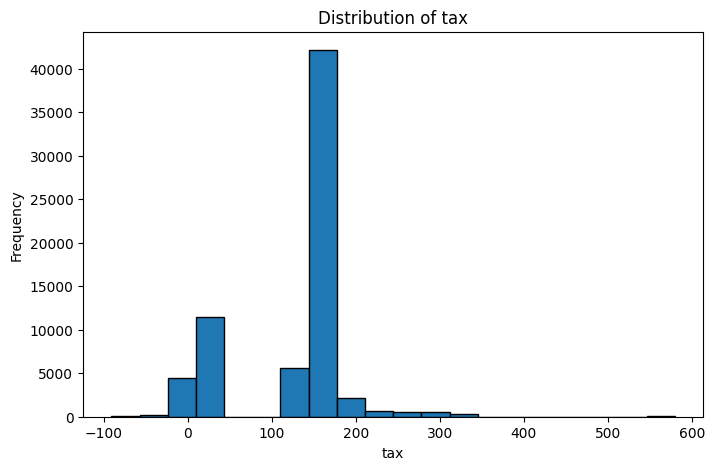

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[df["tax"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0
19457,Ford,FOCUS,2019,18910,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0


In [ ]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

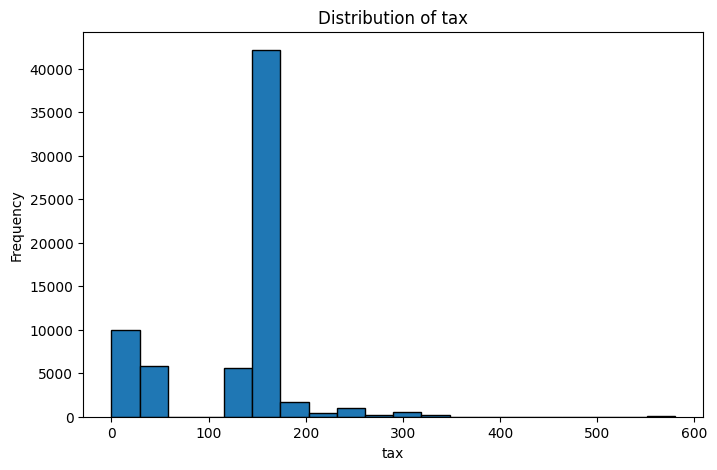

In [ ]:
df=impossible_to_nan(df, "tax")

plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[df["tax"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.300000,1.6,59.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0
19457,Ford,FOCUS,2019,18910,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0


In [ ]:
g = df[df["tax"] == 0]
g["year"].value_counts()

year
2016    1675
2017    1046
2015     827
2014     391
2013     221
2012      26
2011      16
2010      15
2009       5
2018       2
Name: count, dtype: Int64

#### Preprocessing **mpg**

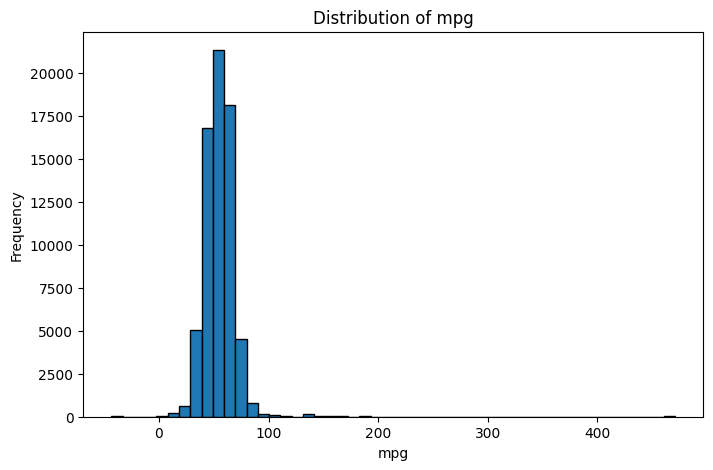

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()
#FIXE

In [ ]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,2019,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


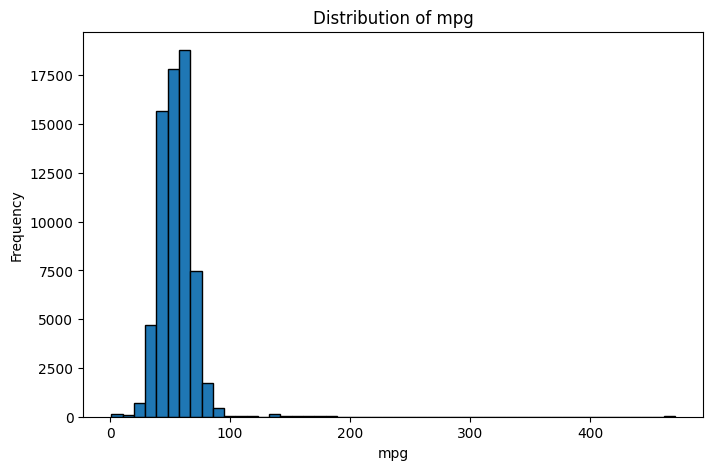

In [ ]:
df=impossible_to_nan(df, "mpg")

plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,2019,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


#### Preprocessing **engineSize**

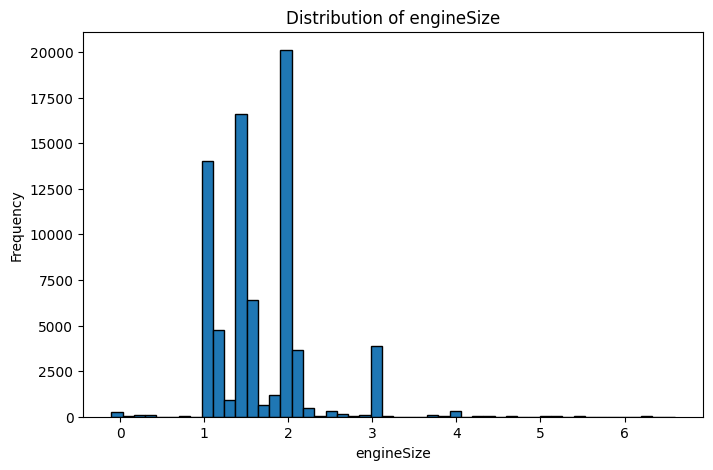

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[df["engineSize"] < 0.6]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,2019,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2018,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
9518,BMW,2SERIES,2015,14700,AUTOMATIC,32882.0,DIESEL,125.0,60.1,0.000000,55.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33307,Hyundai,I10,2018,8500,MANUAL,12948.0,PETROL,145.0,60.1,0.000000,46.0,2.0,0.0
46732,Skoda,OCTAVIA,2018,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,2016,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0


In [ ]:
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,2017,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,2017,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,2017,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,VW,GOLF,2016,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,2019,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,2017,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,2020,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


In [ ]:
df=impossible_to_nan(df, "engineSize", 0.49)
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,2017,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
30317,Ford,None,2019,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,2017,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,2017,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,2015,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,2020,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,2020,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


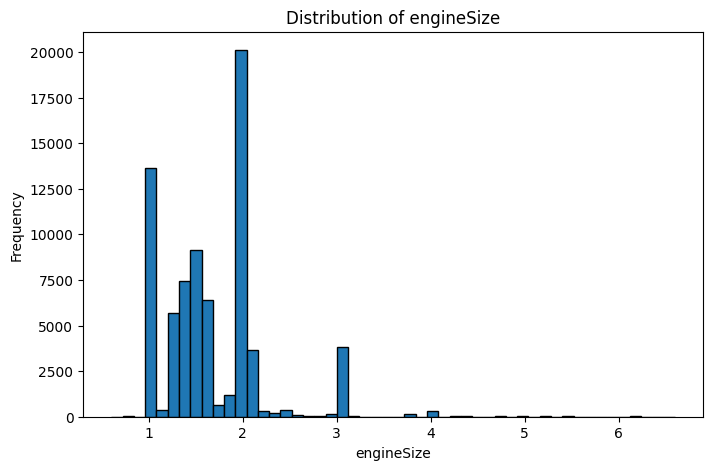

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

#### Preprocessing **paintQuality%**

In [ ]:
df["paintQuality%"].describe()

count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64

In [ ]:
df[df["paintQuality%"] > 100]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
15717,Ford,FIESTA,2018,10491,MANUAL,6522.0,PETROL,145.0,65.7,1.0,125.109951,3.0,0.0
11200,BMW,4SERIES,2019,23591,SEMI-AUTO,6100.0,PETROL,145.0,45.6,2.0,125.569499,2.0,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.0,0.0
48038,Skoda,YETIOUTDOOR,2015,11995,SEMI-AUTO,19805.0,PETROL,125.0,51.4,1.2,125.453599,1.0,0.0
10137,BMW,5SERIES,2017,21995,AUTOMATIC,18820.0,DIESEL,145.0,65.7,2.0,125.569499,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75768,VW,TIGUAN,2018,18499,MANUAL,24940.0,PETROL,145.0,48.7,1.4,125.366507,0.0,0.0
39666,Mercedes,ECLASS,2017,21602,SEMI-AUTO,40690.0,DIESEL,145.0,NaN,3.0,125.202033,3.0,0.0
23930,Ford,FIESTA,2020,15000,MANUAL,35.0,PETROL,145.0,56.5,1.0,125.109951,0.0,0.0


In [ ]:
df[df["paintQuality%"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
25484,Ford,BMAX,2016,9498,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0
41801,Mercedes,CCLASS,2019,49499,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0
55579,Toyota,YARIS,2019,11280,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0
55572,Toyota,AYGO,2019,10195,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013,6698,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0
62623,Opel,MOKKAX,2019,14995,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN
64505,Opel,CORSA,2016,6999,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0


In [ ]:
df = impossible_to_nan(df,"paintQuality%", 100, "upper")
df[df["paintQuality%"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
25484,Ford,BMAX,2016,9498,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0
41801,Mercedes,CCLASS,2019,49499,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0
55579,Toyota,YARIS,2019,11280,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0
55572,Toyota,AYGO,2019,10195,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013,6698,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0
62623,Opel,MOKKAX,2019,14995,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN
64505,Opel,CORSA,2016,6999,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0


In [ ]:
df["paintQuality%"].describe()

count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64

#### Preprocessing **previousOwners**

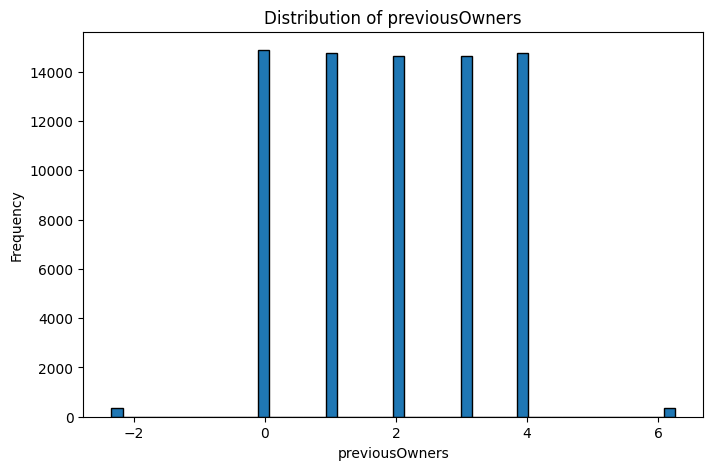

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of previousOwners")
plt.xlabel("previousOwners")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["previousOwners"].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [ ]:
df[df["previousOwners"]<0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
29021,Ford,FIESTA,2018,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,50.0,-2.340306,0.0
71677,VW,TIGUAN,2019,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,42.0,-2.345650,0.0
16962,Ford,FOCUS,2019,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,41.0,-2.340306,0.0
5994,Audi,None,2020,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,98.0,-2.335123,0.0
5038,Audi,RS6,2020,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,72.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,2020,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,62.0,-2.345650,0.0
75599,VW,UP,2015,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,31.0,-2.345650,0.0
28295,Ford,SMAX,2017,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,45.0,-2.340306,0.0


In [ ]:
df[df["previousOwners"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,59.0,NaN,0.0
18304,Ford,None,2016,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,74.0,NaN,0.0
49135,Skoda,SCALA,2020,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,88.0,NaN,0.0
37446,Mercedes,CCLASS,2019,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,87.0,NaN,0.0
1768,Audi,Q3,2020,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,48.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,2014,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,57.0,NaN,0.0
6295,Audi,A3,2018,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,60.0,NaN,0.0
21918,Ford,FIESTA,2019,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,65.0,NaN,0.0


In [ ]:
def round_owners_int(df):
    df=df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")

    df['previousOwners'] = df['previousOwners'].round().astype('Int64')
    return df

In [ ]:
df=impossible_to_nan(df,"previousOwners")
df=round_owners_int(df)
df["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

#### Preprocessing **hasDamage**

In [ ]:
df["hasDamage"].unique() #está cheia de zeros

array([ 0., nan])

In [ ]:
def remove_hasdmg(df):
    df = df.copy()

    df = df.drop(columns=['hasDamage'])
    return df

In [ ]:
df=remove_hasdmg(df)

In [ ]:
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


#### Further Preprocessing

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

print("Missing Values with Percentage:\n")
print(missing_df)



Missing Values with Percentage:

                Missing Count  Missing Percentage
tax                      8282           10.901241
mpg                      7962           10.480039
engineSize               2034            2.677267
previousOwners           1921            2.528530
paintQuality%            1891            2.489042
year                     1851            2.436392
mileage                  1832            2.411383
transmission             1522            2.003343
model                    1520            2.000711
fuelType                 1511            1.988864
Brand                     104            0.136891


In [ ]:
def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna('UNKNOWN')

    return df

In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']

In [ ]:
df=fill_cats_UNKNOWN(df, cat_cols)

In [ ]:
def clean_df(df, valid_models):
    df=df.copy()

    df=carID_como_index(df)
    df=fuzzy_marcas(df)
    df=fuzzy_modelos(df, valid_models)
    df=inferir_marca_com_modelo(df, valid_models)
    df=limpar_anos(df)
    df=fuzzy_transmissao(df)
    df=impossible_to_nan(df, "mileage")
    df=fuzzy_fuel(df)
    df=impossible_to_nan(df, "tax")
    df=impossible_to_nan(df, "mpg")
    df=impossible_to_nan(df, "engineSize", 0.49)
    df=impossible_to_nan(df,"paintQuality%", 100, "upper")
    df=impossible_to_nan(df,"previousOwners")
    df=round_owners_int(df)
    df=remove_hasdmg(df)
    df=fill_cats_UNKNOWN(df,cat_cols)

    return df

In [ ]:
og_df=clean_df(og_df, valid_models)

In [ ]:
assert pd.testing.assert_frame_equal(df, og_df) is None

In [ ]:
def separar_y(df):
    df=df.copy()

    X = df.drop('price', axis = 1)
    y = df['price']

    return X, y

In [ ]:
X, y = separar_y(df)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [ ]:
y

carID
69512    22290
53000    13790
6366     24990
29021    12500
10062    22995
         ...  
37194    13498
6265     12495
54886     8399
860      12990
15795    10495
Name: price, Length: 75973, dtype: int64

# Feature Selection

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, random_state = RANDOM_SEED, shuffle = True)

In [ ]:
df.dtypes

Brand              object
model              object
year                Int64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners      Int64
dtype: object

In [ ]:
def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill

        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X

In [ ]:
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           53181 non-null  object 
 1   model           53181 non-null  object 
 2   year            53181 non-null  Int64  
 3   transmission    53181 non-null  object 
 4   mileage         53181 non-null  float64
 5   fuelType        53181 non-null  object 
 6   tax             53181 non-null  float64
 7   mpg             53181 non-null  float64
 8   engineSize      53181 non-null  float64
 9   paintQuality%   53181 non-null  float64
 10  previousOwners  53181 non-null  Int64  
dtypes: Int64(2), float64(5), object(4)
memory usage: 5.0+ MB


In [ ]:
def plot_nums(X, num_cols):
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")

        plt.tight_layout()
        plt.show()

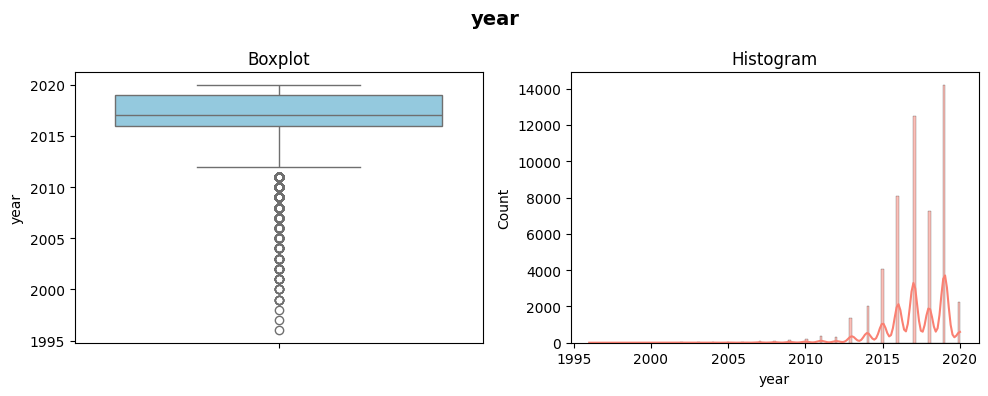

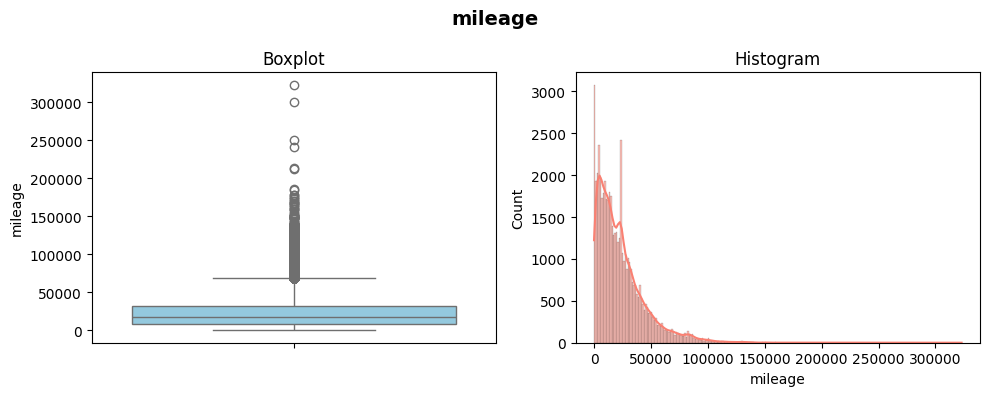

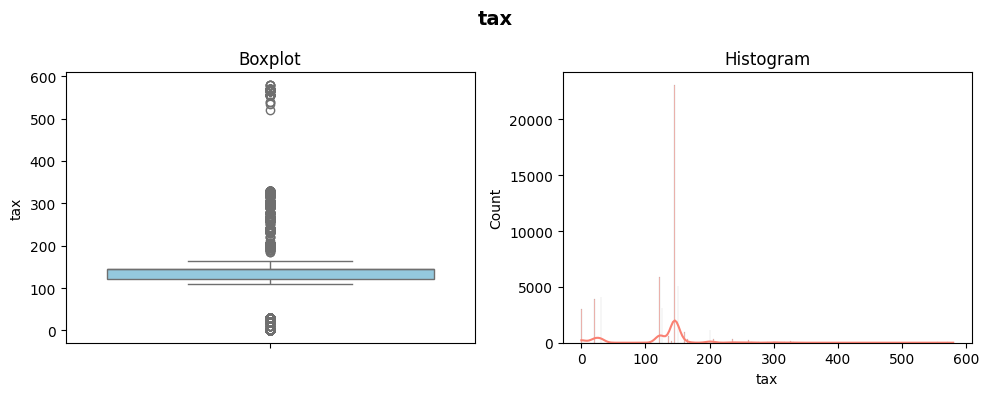

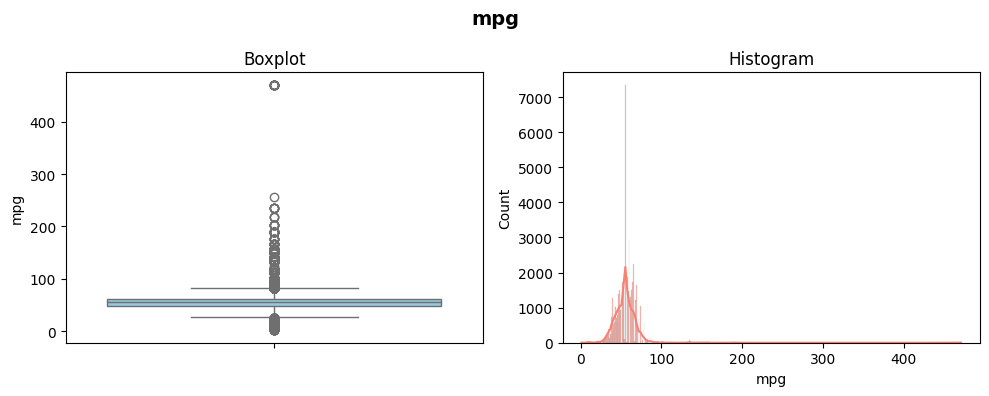

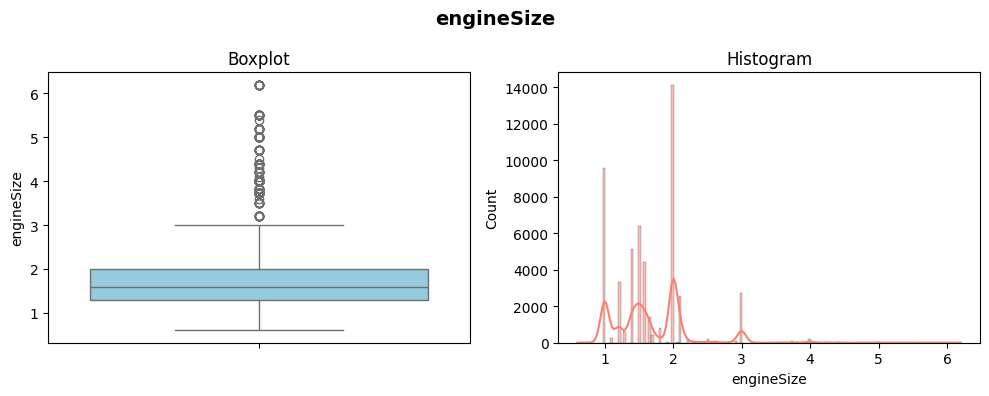

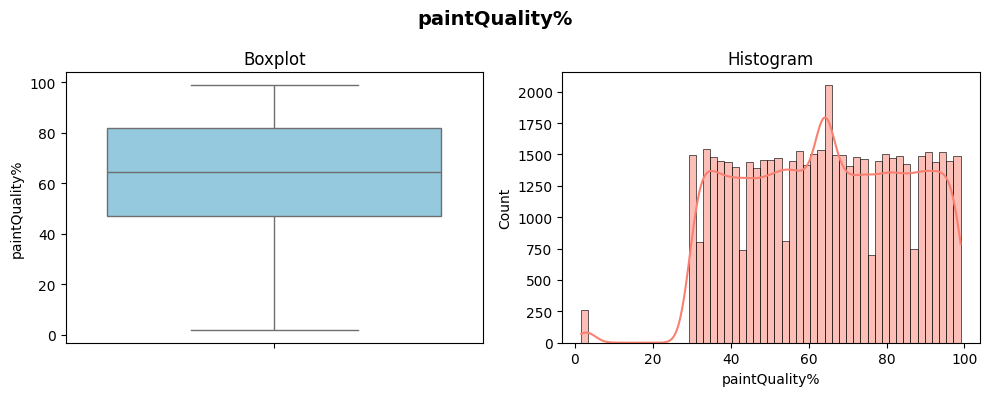

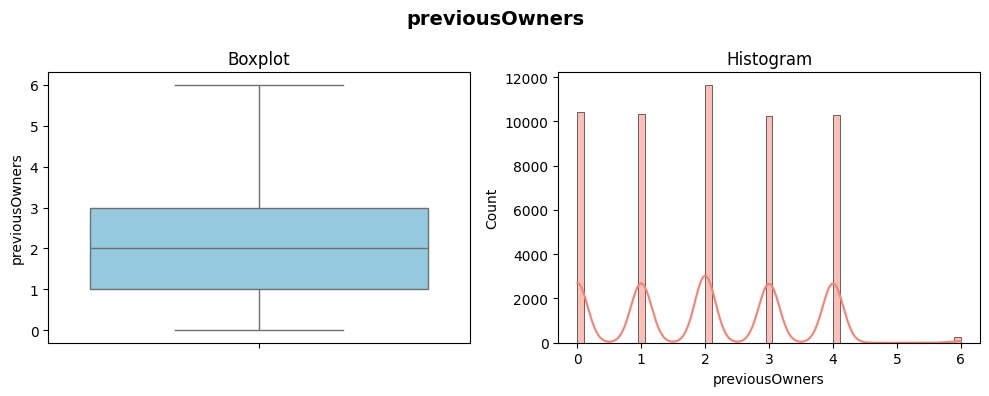

In [ ]:
plot_nums(X_train, num_cols)

In [ ]:
def outliers_skews_train(X):
    X = X.copy()
    outlier_info = {}

    if "mileage" in X.columns:
        X["mileage"] = np.log1p(X["mileage"])
        outlier_info["mileage"] = {"log_transform": True}

    if "tax" in X.columns:
        upper = X["tax"].quantile(0.975)
        X["tax"] = X["tax"].clip(upper=upper)
        outlier_info["tax"] = {"upper": upper}

    if "mpg" in X.columns:
        upper = X["mpg"].quantile(0.975)
        X["mpg"] = X["mpg"].clip(upper=upper)
        outlier_info["mpg"] = {"upper": upper}

    if "engineSize" in X.columns:
        lower = X["engineSize"].quantile(0.01)
        upper = X["engineSize"].quantile(0.99)
        X["engineSize"] = X["engineSize"].clip(lower=lower, upper=upper)
        outlier_info["engineSize"] = {"lower": lower, "upper": upper}

    return X, outlier_info

def outliers_skews_test(X, outlier_info):
    X = X.copy()

    if "mileage" in outlier_info and "mileage" in X.columns:
        if outlier_info["mileage"].get("log_transform", False):
            X["mileage"] = np.log1p(X["mileage"])

    if "tax" in outlier_info and "tax" in X.columns:
        X["tax"] = X["tax"].clip(upper=outlier_info["tax"]["upper"])

    if "mpg" in outlier_info and "mpg" in X.columns:
        X["mpg"] = X["mpg"].clip(upper=outlier_info["mpg"]["upper"])

    if "engineSize" in outlier_info and "engineSize" in X.columns:
        X["engineSize"] = X["engineSize"].clip(
            lower=outlier_info["engineSize"]["lower"],
            upper=outlier_info["engineSize"]["upper"]
        )

    return X

In [ ]:
X_train, outlier_info = outliers_skews_train(X_train)
X_val = outliers_skews_test(X_val, outlier_info)

In [ ]:
X_val

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
7082,Audi,A4,2019,AUTOMATIC,8.580168,PETROL,145.000000,36.200000,2.0,83.0,1
40497,Mercedes,CCLASS,2016,SEMI-AUTO,10.173744,DIESEL,121.445982,55.181389,2.1,71.0,3
46065,Mercedes,ECLASS,2015,AUTOMATIC,10.655446,PETROL,235.000000,28.800000,3.0,43.0,3
17155,Ford,ECOSPORT,2018,MANUAL,9.864019,PETROL,145.000000,54.300000,1.0,60.0,4
34462,Hyundai,I800,2018,UNKNOWN,10.404202,DIESEL,145.000000,37.700000,2.5,62.0,1
...,...,...,...,...,...,...,...,...,...,...,...
50530,Skoda,FABIA,2017,SEMI-AUTO,9.881089,PETROL,145.000000,61.400000,1.0,40.0,2
41012,Mercedes,GLCLASS,2019,SEMI-AUTO,7.902857,DIESEL,145.000000,55.181389,2.0,87.0,2
68389,VW,UP,2017,MANUAL,10.412411,PETROL,20.000000,64.200000,1.0,86.0,2


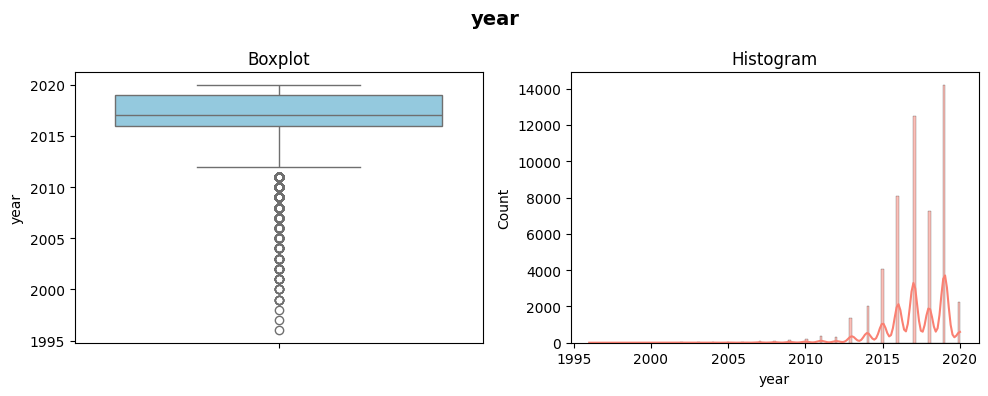

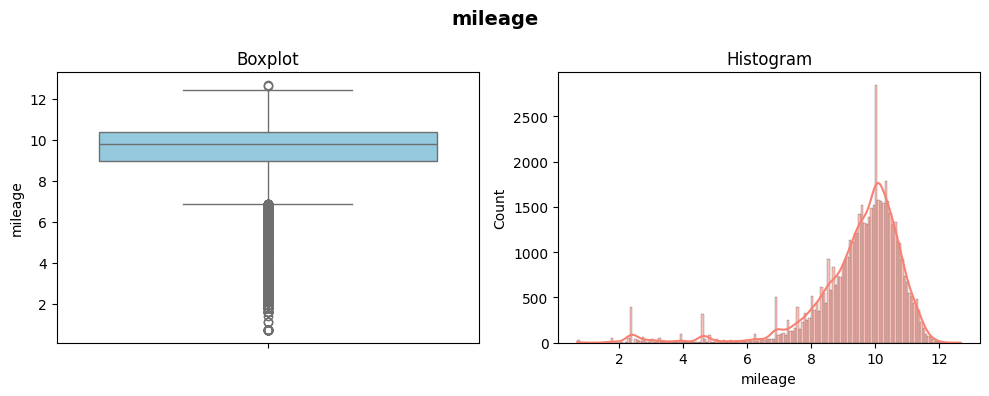

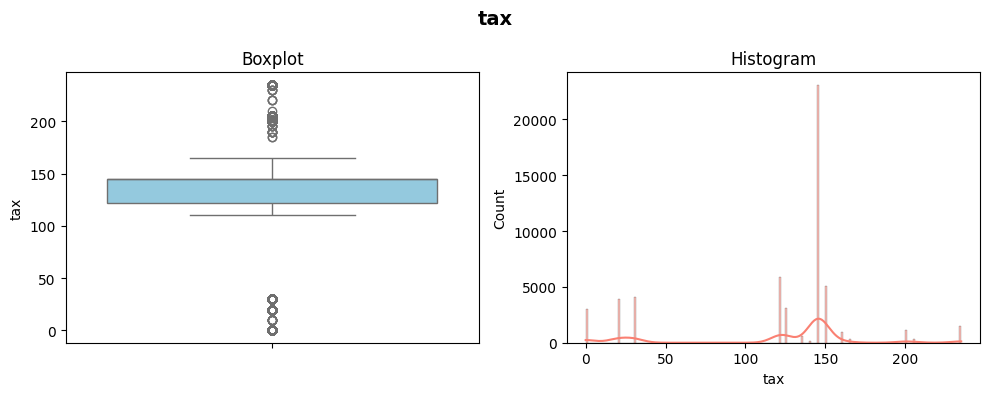

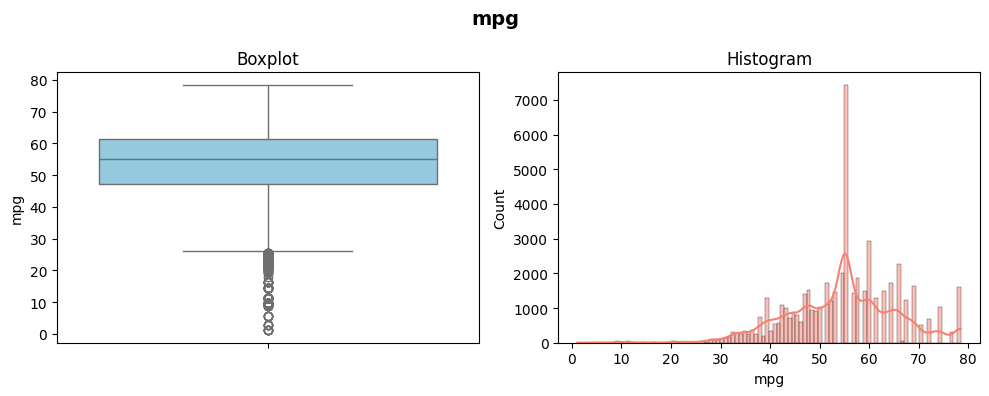

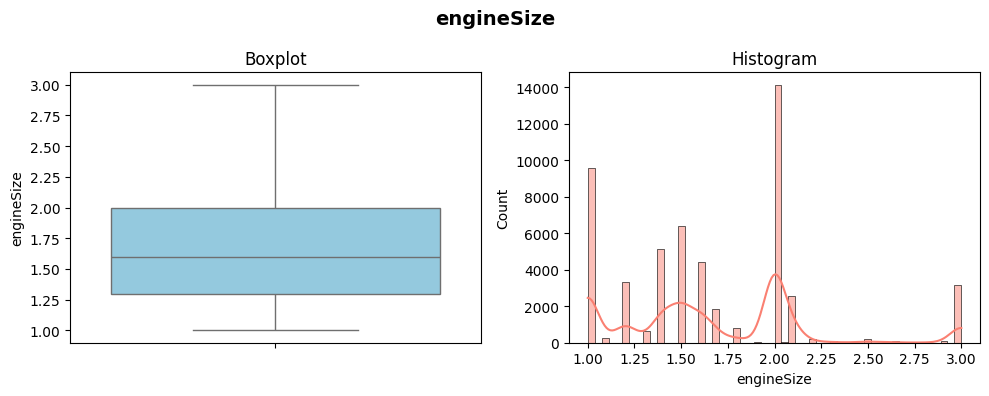

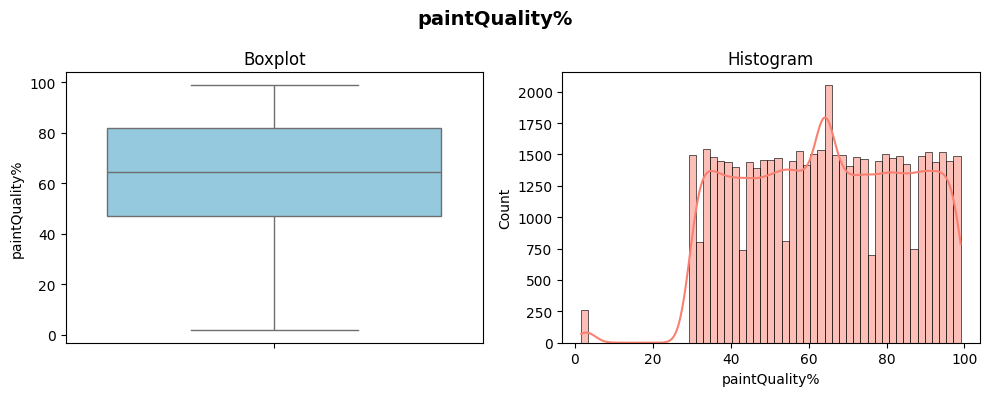

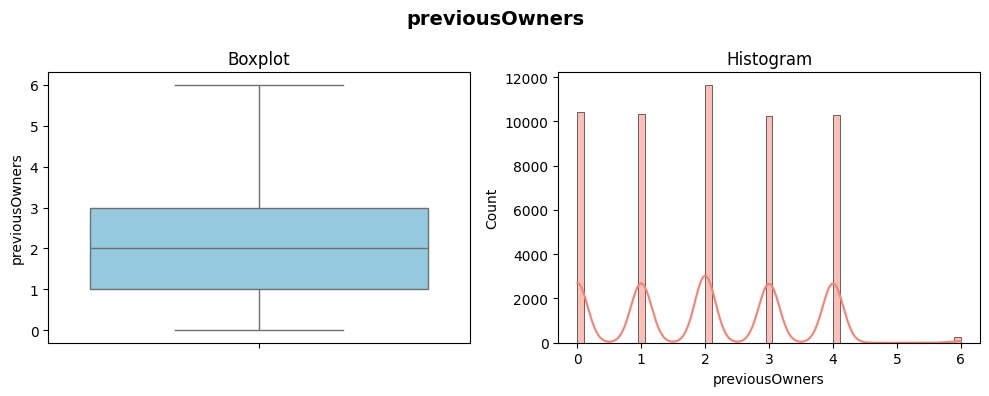

In [ ]:
plot_nums(X_train, num_cols)

In [ ]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[0.95833333, 0.63204739, 0.61702128, ..., 0.15      , 0.45563467,
        0.33333333],
       [0.95833333, 0.66317479, 0.57446809, ..., 0.5       , 0.77403703,
        0.5       ],
       [1.        , 0.14215399, 0.61702128, ..., 0.        , 0.29129797,
        0.        ],
       ...,
       [0.79166667, 0.84176999, 0.08510638, ..., 0.        , 0.68159764,
        0.16666667],
       [0.875     , 0.81978055, 0.53191489, ..., 0.2       , 0.68159764,
        0.66666667],
       [0.79166667, 0.83355055, 0.53191489, ..., 0.55      , 0.53780302,
        0.        ]])

In [ ]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,
39423,0.958333,0.632047,0.617021,0.604651,0.15,0.455635,0.333333
9016,0.958333,0.663175,0.574468,1.000000,0.50,0.774037,0.500000
24121,1.000000,0.142154,0.617021,0.715762,0.00,0.291298,0.000000
57460,0.916667,0.774445,0.617021,0.492248,0.20,0.609700,0.000000
1936,1.000000,0.609856,0.617021,0.361757,0.95,0.917832,0.166667
...,...,...,...,...,...,...,...
33819,0.875000,0.765346,0.516791,0.649871,0.20,0.969187,0.666667
46982,0.958333,0.327042,0.617021,0.538760,0.50,0.702140,0.333333
71103,0.791667,0.841770,0.085106,0.797158,0.00,0.681598,0.166667


In [ ]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,
7082,0.958333,0.657676,0.617021,0.453488,0.50,0.835663,0.166667
40497,0.833333,0.790559,0.516791,0.698726,0.55,0.712411,0.500000
46065,0.791667,0.830727,1.000000,0.357881,1.00,0.424822,0.500000
17155,0.916667,0.764732,0.617021,0.687339,0.00,0.599429,0.666667
34462,0.916667,0.809777,0.617021,0.472868,0.75,0.619971,0.166667
...,...,...,...,...,...,...,...
50530,0.875000,0.766156,0.617021,0.779070,0.00,0.394008,0.333333
41012,0.958333,0.601197,0.617021,0.698726,0.50,0.876747,0.333333
68389,0.875000,0.810461,0.085106,0.815245,0.00,0.866476,0.333333


In [ ]:
X_train_num_scaled.var()


year              0.007781
mileage           0.016104
tax               0.056344
mpg               0.020445
engineSize        0.065608
paintQuality%     0.043909
previousOwners    0.056276
dtype: float64

In [ ]:
X_train_num.var()

year                4.481947
mileage             2.315915
tax               3111.57179
mpg               122.483658
engineSize          0.262432
paintQuality%     416.222702
previousOwners      2.025928
dtype: Float64

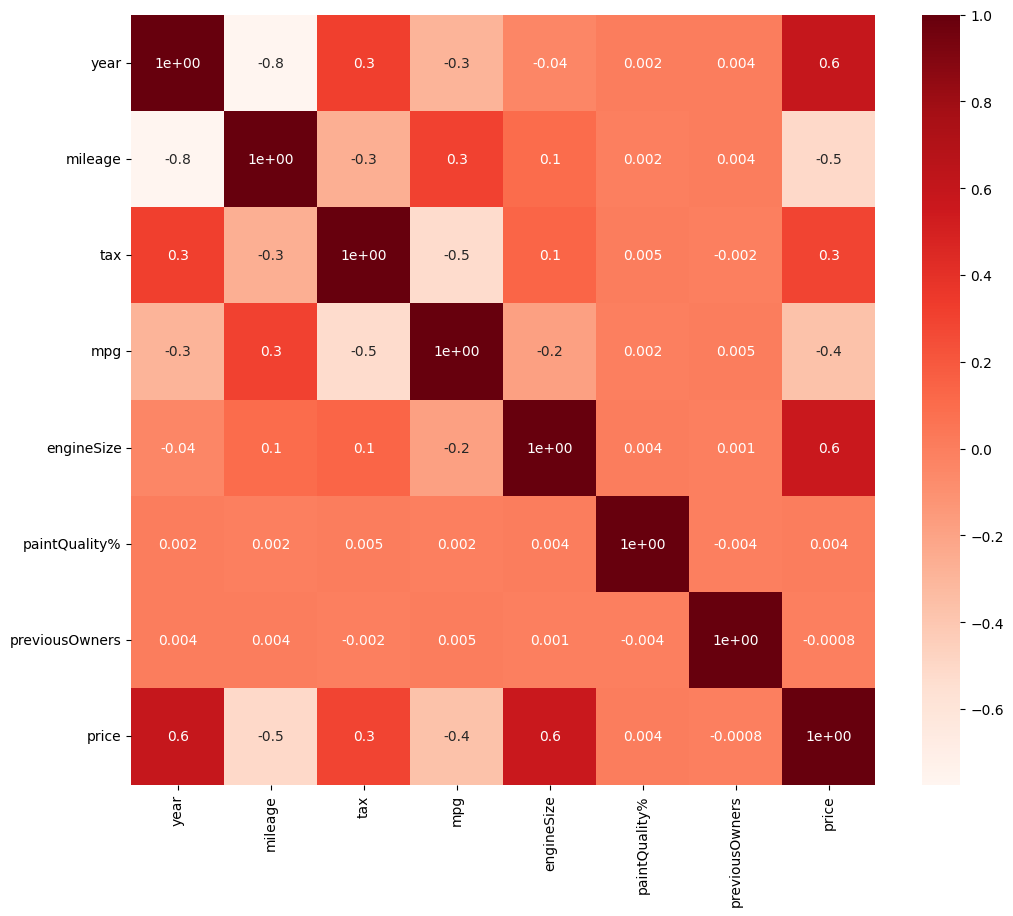

In [ ]:
corr = X_train_num_scaled.assign(price=y_train).corr(method='spearman')
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [ ]:
mi_scores = mutual_info_regression(X_train_num_scaled, y_train, random_state=0)
mi_scores = pd.Series(mi_scores, index=X_train_num_scaled.columns)
mi_scores.sort_values(ascending=False, inplace=True)
print(mi_scores)

engineSize        0.379613
mpg               0.364743
year              0.327638
mileage           0.304339
tax               0.190054
previousOwners    0.005993
paintQuality%     0.000000
dtype: float64


In [ ]:
def TestIndependence(X,y,var,alpha=0.05):
    dfObserved = pd.crosstab(y,X)
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p<alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

for var in X_train_cat:
    TestIndependence(X_train_cat[var],y_train, var)

Brand is IMPORTANT for Prediction
model is IMPORTANT for Prediction
transmission is IMPORTANT for Prediction
fuelType is NOT an important predictor. (Discard fuelType from model)


In [ ]:
def cramers_v(x, y, var):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    result =  np.sqrt(chi2 / (n * (min(k - 1, r - 1))))
    print(f"{var}: {result}")

for var in X_train_cat:
    cramers_v(X_train_cat[var],y_train, var)

Brand: 0.4933647476641014
model: 0.4781827026647914
transmission: 0.4831311924601659
fuelType: 0.4022624471229654


In [ ]:
def mutual_info(X, y, var):
    le = LabelEncoder()
    X_encoded = le.fit_transform(X.astype(str)).reshape(-1, 1)

    mi = mutual_info_classif(X_encoded, y, discrete_features=True, random_state=0)
    print(f"{var}: {mi[0]:.4f}")

for var in X_train_cat:
    mutual_info(X_train_cat[var],y_train, var)

Brand: 0.7444
model: 1.9133
transmission: 0.4324
fuelType: 0.2402


In [ ]:
def anova(X_col, y, var):
    groups = [y[X_col == level] for level in X_col.dropna().unique()]

    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)

    print(f"{var.upper()}")
    print(f"  F-stat:  {f_stat:.3f}")
    print(f"  p-value: {p_val:.6f}")
    print("\n")  # line spacing between variables

    return pd.Series({"F-stat": f_stat, "p-value": p_val}, name=var)


for var in X_train_cat:
    anova(X_train_cat[var],y_train, var)

BRAND
  F-stat:  2381.016
  p-value: 0.000000


MODEL
  F-stat:  360.055
  p-value: 0.000000


TRANSMISSION
  F-stat:  5691.801
  p-value: 0.000000


FUELTYPE
  F-stat:  516.946
  p-value: 0.000000




**ANOVA** says: “These features cause significant average price differences.”

**MI** says: “These features explain uncertainty in price (model gives the most info).”

**Cramer’s V** says: “These variables have moderate categorical association strength."

In [ ]:
model = LinearRegression()

In [ ]:
rfe = RFE(estimator = model, n_features_to_select = 4)

In [ ]:
X_rfe = rfe.fit_transform(X = X_train_num_scaled, y = y_train)

In [ ]:
X_train_num_scaled.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners'],
      dtype='object')

In [ ]:
rfe.support_

array([ True,  True, False,  True,  True, False, False])

In [ ]:
rfe.ranking_

array([1, 1, 2, 1, 1, 3, 4])

In [ ]:
selected_features = pd.Series(rfe.support_, index = X_train_num_scaled.columns)
selected_features

year               True
mileage            True
tax               False
mpg                True
engineSize         True
paintQuality%     False
previousOwners    False
dtype: bool

In [ ]:
print(X_train_num_scaled.shape)
print(X_val_num_scaled.shape)
print(y_train.shape)
print(y_val.shape)


(53181, 7)
(22792, 7)
(53181,)
(22792,)


In [ ]:
nof_list = np.arange(1, len(X_train_num_scaled.columns) + 1)
best_score = np.inf
best_n = 0

train_score_list = []
val_score_list = []

for n in nof_list:
    model = LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n)

    # Fit RFE on training data
    X_train_rfe = rfe.fit_transform(X_train_num_scaled, y_train)
    X_val_rfe = rfe.transform(X_val_num_scaled)

    # Fit model
    model.fit(X_train_rfe, y_train)

    # Predict
    y_train_pred = model.predict(X_train_rfe)
    y_val_pred = model.predict(X_val_rfe)

    # Compute RMSE manually
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Store negated RMSE (so higher = better for plotting)
    train_score_list.append(-train_rmse)
    val_score_list.append(-val_rmse)

    # Track best score (lowest RMSE)
    if val_rmse < best_score:
        best_score = val_rmse
        best_n = n

print(f"Optimum number of features: {best_n}")
print(f"Lowest validation RMSE ({best_n} features): {best_score:.4f}")


Optimum number of features: 5
Lowest validation RMSE (5 features): 5378.4385


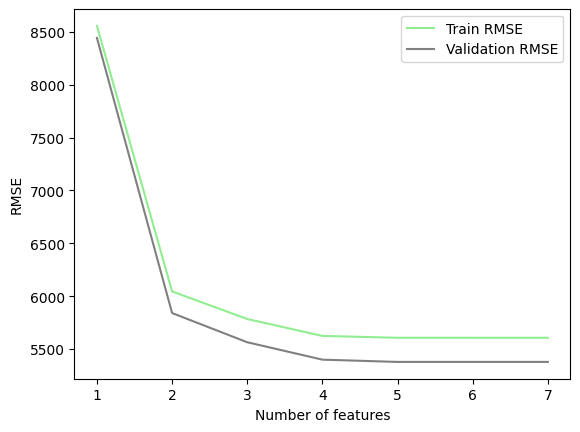

'Acho que há colinearidade entre variáveis como vimos antes, acho 4 sao suifciente'

In [ ]:
plt.plot(nof_list, [-s for s in train_score_list], label='Train RMSE', color='lightgreen')
plt.plot(nof_list, [-s for s in val_score_list], label='Validation RMSE', color='gray')
plt.xlabel('Number of features')
plt.ylabel('RMSE')
plt.legend()
plt.show()

"""Acho que há colinearidade entre variáveis como vimos antes, acho 4 sao suifciente"""

In [ ]:
"""SVR demora muito"""

'SVR demora muito'

In [ ]:
#not sure if allowed
"""#EFS é exaustivo, tenta TODAS as combinações de preditores, não usar cross validation aqui para não ter data leakage
#é permitido?
efs = EFS(
    estimator=model,
    min_features=1,
    max_features=len(X_train_num_scaled.columns),
    scoring=make_scorer(mean_squared_error, greater_is_better=False),
    n_jobs=-1            # parallelize
)

efs = efs.fit(X_train_num_scaled, y_train)
rmse_train = np.sqrt(-efs.best_score_)

print("Best features:", efs.best_feature_names_)
print(f"Training RMSE: {rmse_train:.2f}")
"""

'#EFS é exaustivo, tenta TODAS as combinações de preditores, não usar cross validation aqui para não ter data leakage\n#é permitido?\nefs = EFS(\n    estimator=model,\n    min_features=1,\n    max_features=len(X_train_num_scaled.columns),\n    scoring=make_scorer(mean_squared_error, greater_is_better=False),\n    n_jobs=-1            # parallelize\n)\n\nefs = efs.fit(X_train_num_scaled, y_train)  \nrmse_train = np.sqrt(-efs.best_score_)\n\nprint("Best features:", efs.best_feature_names_)\nprint(f"Training RMSE: {rmse_train:.2f}")\n'

In [ ]:
"""selected = list(efs.best_feature_names_)

model.fit(X_train_num_scaled[selected], y_train)
y_val_pred = model.predict(X_val_num_scaled[selected])

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Validation RMSE: {rmse_val:.2f}")"""

'selected = list(efs.best_feature_names_)\n\nmodel.fit(X_train_num_scaled[selected], y_train)\ny_val_pred = model.predict(X_val_num_scaled[selected])\n\nrmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))\nprint(f"Validation RMSE: {rmse_val:.2f}")'

In [ ]:
reg = LassoCV()

In [ ]:
reg.fit(X_train_num_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [ ]:
coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)
coef.sort_values()

mileage          -14141.696977
mpg              -11896.597076
tax               -2172.830153
paintQuality%      -107.629734
previousOwners      -20.759555
engineSize        22294.266756
year              42233.546583
dtype: float64

In [ ]:
# CODE HERE
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 7 variables and eliminated the other 0 variables


In [ ]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8,10))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

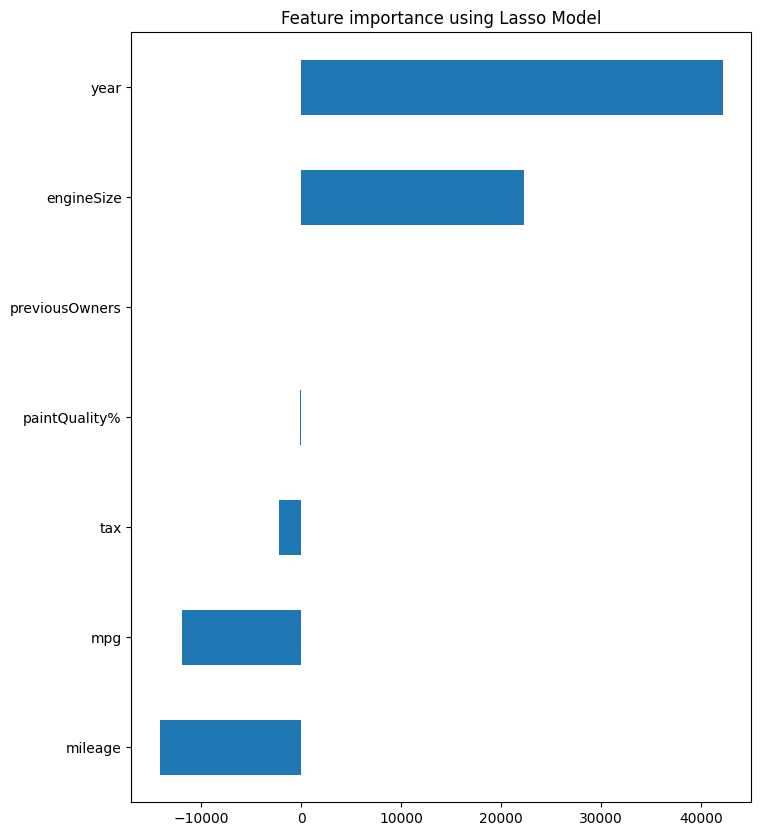

In [ ]:
# CODE HERE
plot_importance(coef,'Lasso')


### Numerical Data
| Feature            | Spearman | Mutual Info | RFE (LR) | Lasso | Decision     |
| ------------------ | -------- | ----------- | -------- | ----- | ------------ |
| **year**           | ✅        | ✅           | ✅        | ✅     | **Keep**     |
| **mileage**        | ❌        | ✅           | ✅        | ❌     | **Keep**     |
| **tax**            | ✅        | ❌           | ❌        | ❌     | Try          |
| **mpg**            | ❌        | ✅           | ✅        | ✅     | **Keep**     |
| **engineSize**     | ✅        | ✅           | ✅        | ✅     | **Keep**     |
| **paintQuality%**  | ❌        | ❌           | ❌        | ❌     | Discard      |
| **previousOwners** | ❌        | ❌           | ❌        | ❌     | Discard      |




### Categorical Data
| Feature          | Chi-Square | Cramér’s V | ANOVA F-test | Decision |
| ---------------- | ---------- | ---------- | ------------ | -------- |
| **brand**        | ✅          | ✅          | ✅            | **Keep** |
| **model**        | ✅          | ✅          | ✅            | **Keep** |
| **transmission** | ✅          | ✅          | ✅            | **Keep** |
| **fuelType**     | ❌          | ❌          | ✅            | Discard  |

Conclusion:

The most predictive features for our car price model appear to be:

Numerical: year, engineSize, mpg

Categorical: brand, model, transmission

# Model Selection

In [ ]:
"""Frequency encoding logic"""
def frequency_encode_train(df, cat_cols):
    df_encoded = df.copy()

    freq_values = {}
    for col in cat_cols:
        freq_map = df[col].value_counts(normalize=True)

        #this needed in order to not have data leakage when applying to test data, there will be classes that are not in the training dataset
        #due to the fact that the strings were corrupted and pre processing isnt perfect of course
        mean_freq = freq_map.mean()
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
        freq_values[col] = {
            "map": freq_map,
            "mean": mean_freq
        }

    return df_encoded, freq_values

In [ ]:
def frequency_encode_test(df, cat_cols, freq_values):
    df_encoded = df.copy()

    for col in cat_cols:
        freq_map = freq_values[col]["map"]
        mean_freq = freq_values[col]["mean"]
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
    return df_encoded

In [ ]:
def run_model(X, y, int_cols, float_cols, model, scaler=None, encoder=None, cat_cols=None, encoding_type="ohe"):
    X_processed = X.copy()

    X_processed, fill_values = fill_nans(X_processed, int_cols, float_cols)

    X_processed, outlier_info = outliers_skews_train(X_processed)

    freq_values = None
    train_feature_cols = None

    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type == "ohe" and encoder is not None:
            encoder.fit(X_processed[cat_cols])
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_encoded = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)
            X_processed = X_encoded

        elif encoding_type == "freq":
            X_processed, freq_values = frequency_encode_train(X_processed, cat_cols)

    train_feature_cols = X_processed.columns.tolist()

    if scaler is not None:
        numeric_cols = [col for col in X_processed.columns if col in (int_cols + float_cols)]
        X_processed[numeric_cols] = scaler.fit_transform(X_processed[numeric_cols])

    model.fit(X_processed, y)

    return model, scaler, encoder, fill_values, train_feature_cols, freq_values, outlier_info

In [ ]:
def evaluate_model(X, y, model, int_cols, float_cols, fill_values,
                   scaler=None, encoder=None, cat_cols=None,
                   train_feature_cols=None, freq_values=None, outlier_info=None,
                   encoding_type="ohe", return_predictions=False):
    X_processed = X.copy()

    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    if outlier_info is not None:
        X_processed = outliers_skews_test(X_processed, outlier_info)

    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type == "ohe" and encoder is not None:
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_encoded = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)

            # Align to training columns
            X_encoded = X_encoded.reindex(columns=train_feature_cols, fill_value=0)
            X_processed = X_encoded

        elif encoding_type == "freq":
            X_processed = frequency_encode_test(X_processed, cat_cols, freq_values)

    if scaler is not None:
        numeric_cols = [col for col in X_processed.columns if col in (int_cols + float_cols)]
        X_processed[numeric_cols] = scaler.fit_transform(X_processed[numeric_cols])

    preds = model.predict(X_processed)
    if return_predictions:
        return preds
    else:
        return model.score(X_processed, y)


In [ ]:
def avg_score(method, X, y, int_cols, float_cols, model,
              scaler=None, encoder=None, cat_cols=None, encoding_type="ohe"):
    mae_train, mae_val = [], []
    r2_train, r2_val = [], []

    for train_index, val_index in method.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        trained_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
            X_train, y_train, int_cols, float_cols, model,
            scaler, encoder, cat_cols, encoding_type
        )

        y_train_pred = evaluate_model(
            X_train, y_train, trained_model, int_cols, float_cols, fill_values,
            fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
            freq_values, outlier_info, encoding_type, return_predictions=True
        )

        y_val_pred = evaluate_model(
            X_val, y_val, trained_model, int_cols, float_cols, fill_values,
            fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
            freq_values, outlier_info, encoding_type, return_predictions=True
        )

        mae_train.append(mean_absolute_error(y_train, y_train_pred))
        mae_val.append(mean_absolute_error(y_val, y_val_pred))
        r2_train.append(r2_score(y_train, y_train_pred))
        r2_val.append(r2_score(y_val, y_val_pred))

    final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
        X, y, int_cols, float_cols, model, scaler, encoder, cat_cols, encoding_type
    )

    print(f"Average Train MAE: {np.mean(mae_train):.4f}")
    print(f"Average Val MAE:   {np.mean(mae_val):.4f}")
    print(f"Average Train R²:  {np.mean(r2_train):.4f}")
    print(f"Average Val R²:    {np.mean(r2_val):.4f}")

    return {
        "mae_train": mae_train,
        "mae_val": mae_val,
        "r2_train": r2_train,
        "r2_val": r2_val,
        "final_model": final_model,
        "fitted_scaler": fitted_scaler,
        "fitted_encoder": fitted_encoder,
        "fill_values": fill_values,
        "train_feature_cols": train_feature_cols,
        "freq_values": freq_values,
        "outlier_info": outlier_info
    }


In [ ]:
def predict_test(X_test, model, int_cols, float_cols, fill_values,
                 scaler=None, encoder=None, cat_cols=None,
                 train_feature_cols=None, freq_values=None,
                 outlier_info=None, encoding_type="ohe"):
    X_processed = X_test.copy()

    # Fill missing values
    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    # Encode categorical features
    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type=="ohe" and encoder is not None:
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_encoded = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)

            # Align to full training feature list
            X_encoded = X_encoded.reindex(columns=train_feature_cols, fill_value=0)
            X_processed = X_encoded

        elif encoding_type == "freq":
            X_processed = frequency_encode_test(X_processed, cat_cols, freq_values)

    # Scale features
    if scaler is not None:
        numeric_cols = [col for col in X_processed.columns if col in (int_cols + float_cols)]
        X_processed[numeric_cols] = scaler.fit_transform(X_processed[numeric_cols])

    # Handle outliers / skews
    if outlier_info is not None:
        X_processed = outliers_skews_test(X_processed, outlier_info)

    return model.predict(X_processed)

# Model 1

## Attempt #1 : Linear Regression (All features, StandardScaler)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")

In [ ]:
model = LinearRegression()

In [ ]:
scaler = StandardScaler()

In [ ]:
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [ ]:
results = avg_score(
    method=kf,
    X=X,
    y=y,
    int_cols=int_cols,
    float_cols=float_cols,
    model=model,
    scaler=scaler,
    encoder=ohe,
    cat_cols=cat_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sk

Average Train MAE: 2495.6576
Average Val MAE:   2507.2807
Average Train R²:  0.8294
Average Val R²:    0.8272


In [ ]:
results

{'mae_train': [2489.7203191897893,
  2499.2258903745783,
  2497.048341954941,
  2507.8373868119534,
  2497.1740369129716,
  2486.894668342286,
  2491.702505822876],
 'mae_val': [2519.5064099075025,
  2486.80050349548,
  2495.570808636051,
  2472.08134874576,
  2497.5855817573856,
  2542.559307511482,
  2536.860861159605],
 'r2_train': [0.8300736899615451,
  0.8271263159509303,
  0.8283981672413087,
  0.8269975922470578,
  0.8297035959176096,
  0.8333295219347977,
  0.8299536395296317],
 'r2_val': [0.8222250925028957,
  0.8406975040287914,
  0.833414347892214,
  0.8408804117900853,
  0.825204640004681,
  0.8042241704725532,
  0.823855569546939],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fitted_encoder': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'fill_values': {'float': {'mileage': np.float64(23352.797091695324),
   'tax': np.float64(121.25927623394078),
   'mpg': np.float64(55.204844209618095),
   'engineSize': np.float64

In [ ]:
model = results["final_model"]
scaler = results["fitted_scaler"]
encoder = results["fitted_encoder"]
fill_values = results["fill_values"]
train_feature_cols = results["train_feature_cols"]
#this is used right below for testing

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [ ]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [ ]:
len(X_test)

32567

In [ ]:
y_pred = predict_test(
    X_test,
    model=model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=scaler,
    encoder=encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model1.csv", index=False)

,carID,price
0,89856,14539.543610
1,106581,23777.973867
2,80886,13682.846557
3,100174,18733.037931
4,81376,22529.090547


In [ ]:
submission

,carID,price
0,89856,14539.543610
1,106581,23777.973867
2,80886,13682.846557
3,100174,18733.037931
4,81376,22529.090547
...,...,...
32562,105775,17416.024984
32563,81363,30293.297703
32564,76833,32690.318722
32565,91768,22144.637217


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

# Model 2

## Attempt #2 : Linear Regression (Selected Features 1)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
X = X.drop(columns=drop_cols)

In [ ]:
display(X)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,NaN,11.417268,2.0
53000,Toyota,YARIS,2019,MANUAL,4589.0,145.0,47.900000,1.5
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,145.0,40.900000,1.5
29021,Ford,FIESTA,2018,MANUAL,9102.0,145.0,65.700000,1.0
10062,BMW,2SERIES,2019,MANUAL,1000.0,145.0,42.800000,1.5
...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,125.0,53.300000,2.0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,200.0,47.900000,2.0
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,145.0,67.000000,1.0


In [ ]:
model = LinearRegression()
scaler = StandardScaler()
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")

In [ ]:
results = avg_score(
    method=kf,
    X=X,
    y=y,
    int_cols=int_cols,
    float_cols=float_cols,
    model=model,
    scaler=scaler,
    encoder=ohe,
    cat_cols=cat_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sk

Average Train MAE: 2525.4264
Average Val MAE:   2536.9814
Average Train R²:  0.8260
Average Val R²:    0.8238


In [ ]:
results

{'mae_train': [2518.596011756436,
  2527.970396088613,
  2527.495330402924,
  2539.387601492886,
  2526.736512579332,
  2516.572058550258,
  2521.226999463961],
 'mae_val': [2550.2587405275194,
  2522.6026885005112,
  2522.4731032441787,
  2491.271094851734,
  2530.404037998782,
  2572.7620181470297,
  2569.0982474489147],
 'r2_train': [0.8267801683026821,
  0.8237969338349038,
  0.8249594528938337,
  0.8233969743265729,
  0.8264089163760523,
  0.8299721503379931,
  0.8266390377423644],
 'r2_val': [0.8183220002584135,
  0.8370867929237578,
  0.8304301086765155,
  0.8388630081219189,
  0.8213579345857747,
  0.8007053625329346,
  0.8201145749830017],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fitted_encoder': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'fill_values': {'float': {'mileage': np.float64(23352.797091695324),
   'tax': np.float64(121.25927623394078),
   'mpg': np.float64(55.204844209618095),
   'engineSize': np.flo

In [ ]:
model = results["final_model"]
scaler = results["fitted_scaler"]
encoder = results["fitted_encoder"]
fill_values = results["fill_values"]
train_feature_cols = results["train_feature_cols"]
#this is used right below for testing

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [ ]:
display(XcarID)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,150.0,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,125.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,145.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,150.0,51.4,2.0
...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,145.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,145.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,145.0,38.2,2.0


In [ ]:
len(X_test)

32567

In [ ]:
y_pred = predict_test(
    X_test,
    model=model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=scaler,
    encoder=encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model2.csv", index=False)

,carID,price
0,89856,14470.837583
1,106581,23029.598050
2,80886,13666.880042
3,100174,18330.987857
4,81376,23134.873001


In [ ]:
submission

,carID,price
0,89856,14470.837583
1,106581,23029.598050
2,80886,13666.880042
3,100174,18330.987857
4,81376,23134.873001
...,...,...
32562,105775,16711.207727
32563,81363,29898.061658
32564,76833,33122.646246
32565,91768,21891.225341


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

# Model 3

## Attempt #3 : Linear Regression (Selected Features 3)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
num_cols = ['year', 'mileage', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType', 'tax']
X = X.drop(columns=drop_cols)

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
model = LinearRegression()
scaler = StandardScaler()
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
results = avg_score(
    method=kf,
    X=X,
    y=y,
    int_cols=int_cols,
    float_cols=float_cols,
    model=model,
    scaler=scaler,
    encoder=ohe,
    cat_cols=cat_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sk

Average Train MAE: 2536.8035
Average Val MAE:   2548.2213
Average Train R²:  0.8237
Average Val R²:    0.8216


In [ ]:
results

{'mae_train': [2530.081394394755,
  2539.2691249007985,
  2538.194658455498,
  2550.985058412619,
  2537.02499192318,
  2528.6687546789567,
  2533.400330367862],
 'mae_val': [2564.9644564454084,
  2533.4697176912086,
  2538.6409977037397,
  2497.2612606346115,
  2555.283362217825,
  2574.195366139266,
  2573.733663275811],
 'r2_train': [0.824597845153598,
  0.8215350262325352,
  0.8227372076425333,
  0.8210366006855595,
  0.8242580220712261,
  0.8276548036071629,
  0.8244046977473392],
 'r2_val': [0.815645934750384,
  0.8348780391049699,
  0.8279806494085137,
  0.8374222366836397,
  0.8185004728741849,
  0.7988665439247216,
  0.8177305183625414],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fitted_encoder': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
 'fill_values': {'float': {'mileage': np.float64(23352.797091695324),
   'mpg': np.float64(55.204844209618095),
   'engineSize': np.float64(1.6710558716569128)},
  'int': {'year':

In [ ]:
model = results["final_model"]
scaler = results["fitted_scaler"]
encoder = results["fitted_encoder"]
fill_values = results["fill_values"]
train_feature_cols = results["train_feature_cols"]
#this is used right below for testing

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [ ]:
len(X_test)

32567

In [ ]:
y_pred = predict_test(
    X_test,
    model=model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=scaler,
    encoder=encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model3.csv", index=False)

,carID,price
0,89856,14966.057568
1,106581,22875.340767
2,80886,13651.275790
3,100174,18163.054801
4,81376,23243.779025


In [ ]:
submission

,carID,price
0,89856,14966.057568
1,106581,22875.340767
2,80886,13651.275790
3,100174,18163.054801
4,81376,23243.779025
...,...,...
32562,105775,16740.911296
32563,81363,29643.585288
32564,76833,32789.096871
32565,91768,21658.799370


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()


np.True_

# Model 4

## Attempt #4 : Random Forest (All Features, OHE Encoding)

In [ ]:
def random_search_cv(
    X, y,
    int_cols, float_cols, cat_cols,
    model_class=RandomForestRegressor,
    param_dist=None,
    n_iter=30,
    method=None,
    scaler=None,
    encoder=None,
    encoding_type="ohe",
    random_seed=42
):

    if param_dist is None:
        param_dist = {
            "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
            "max_depth": [5, 7, 10, 15, 20, 25, 30],
            "min_samples_split": [2, 4, 5, 10, 12, 15],
            "min_samples_leaf": [1, 2, 5, 7, 10],
            "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
            "max_samples": [0.7, 0.8, 0.9],
            "bootstrap": [True]
        }

    #Randomly sample n_iter parameter combinations
    param_samples = [
        {key: random.choice(values) for key, values in param_dist.items()}
        for _ in range(n_iter)
    ]

    #Default to 7-fold CV if not specified
    if method is None:
        method = KFold(n_splits=7, shuffle=True, random_state=random_seed)

    cv_search_results = []

    print(f"\nRandomized Search with {method.get_n_splits()}-Fold CV (MAE Optimization)")
    print(f"Testing {n_iter} random parameter combinations\n")

    for i, params in enumerate(param_samples, start=1):
        fold_mae_train, fold_r2_train = [], []
        fold_mae_val, fold_r2_val = [], []

        print(f"► Combination {i}/{n_iter}: {params}")

        for fold, (train_idx, val_idx) in enumerate(method.split(X, y), start=1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


            model = model_class(random_state=random_seed, n_jobs=-1, **params)


            trained_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
                X_train, y_train, int_cols, float_cols, model,
                scaler, encoder, cat_cols, encoding_type
            )

            y_train_pred = evaluate_model(
                X_train, y_train, trained_model, int_cols, float_cols, fill_values,
                fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
                freq_values, outlier_info, encoding_type, return_predictions=True
            )

            y_val_pred = evaluate_model(
                X_val, y_val, trained_model, int_cols, float_cols, fill_values,
                fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
                freq_values, outlier_info, encoding_type, return_predictions=True
            )

            # Compute metrics
            mae_train = mean_absolute_error(y_train, y_train_pred)
            mae_val = mean_absolute_error(y_val, y_val_pred)
            r2_train = r2_score(y_train, y_train_pred)
            r2_val = r2_score(y_val, y_val_pred)

            fold_mae_train.append(mae_train)
            fold_mae_val.append(mae_val)
            fold_r2_train.append(r2_train)
            fold_r2_val.append(r2_val)

            print(f"   Fold {fold}: Train MAE = {mae_train:.4f}, Val MAE = {mae_val:.4f}, "
                  f"Train R² = {r2_train:.4f}, Val R² = {r2_val:.4f}")

        mean_mae_train = np.mean(fold_mae_train)
        mean_mae_val = np.mean(fold_mae_val)
        mean_r2_train = np.mean(fold_r2_train)
        mean_r2_val = np.mean(fold_r2_val)

        cv_search_results.append({
            **params,
            "mean_mae_train": mean_mae_train,
            "mean_mae_val": mean_mae_val,
            "mean_r2_train": mean_r2_train,
            "mean_r2_val": mean_r2_val
        })

        print(f"→ Avg Train MAE: {mean_mae_train:.4f} | Avg Val MAE: {mean_mae_val:.4f} | "
              f"Avg Train R²: {mean_r2_train:.4f} | Avg Val R²: {mean_r2_val:.4f}\n")

    #best parameter combo
    best_result = min(cv_search_results, key=lambda x: x["mean_mae_val"])
    best_params = {k: v for k, v in best_result.items()
                   if not k.startswith("mean_")}

    print("\nBest Parameters (based on lowest validation MAE):")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    print(f"\nBest Train MAE: {best_result['mean_mae_train']:.4f}")
    print(f"Best Val MAE:   {best_result['mean_mae_val']:.4f}")
    print(f"Best Train R²:  {best_result['mean_r2_train']:.4f}")
    print(f"Best Val R²:    {best_result['mean_r2_val']:.4f}")

    return {
        "cv_results": cv_search_results,
        "best_result": best_result,
        "best_params": best_params
    }


In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
scaler=None

In [ ]:
#DO NOT run the grid search again, the parameters are hard coded below!!!!!!!!!
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    encoder=ohe,
    encoding_type="ohe",
    random_seed=RANDOM_SEED
)"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    encoder=ohe,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED\n)'

In [ ]:
"""best_params = results["best_params"]
best_params
Best Train MAE: 836.3260
Best Val MAE:   1418.6834
Best Train R²:  0.9752
Best Val R²:    0.9329

"""

'best_params = results["best_params"]\nbest_params\nBest Train MAE: 836.3260\nBest Val MAE:   1418.6834\nBest Train R²:  0.9752\nBest Val R²:    0.9329\n\n'

In [ ]:
best_params = {'n_estimators': 150,
 'max_depth': 30,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}

In [ ]:
rf_model = RandomForestRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    **best_params
)

final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    model=rf_model,
    scaler=scaler,
    encoder=ohe,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [ ]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    encoding_type="ohe",
    outlier_info=outlier_info
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model4.csv", index=False)

,carID,price
0,89856,13523.431679
1,106581,23986.921302
2,80886,13612.648635
3,100174,16850.701513
4,81376,26275.978361


In [ ]:
submission

,carID,price
0,89856,13523.431679
1,106581,23986.921302
2,80886,13612.648635
3,100174,16850.701513
4,81376,26275.978361
...,...,...
32562,105775,17707.009474
32563,81363,35911.421175
32564,76833,33925.060942
32565,91768,20321.833968


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

# Model 5

## Attempt #5: Random Forest (All Features, Frequency Encoding)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']

In [ ]:
#DO NOT run the grid search again, the parameters are hard coded below!!!!!!!!!
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    encoder=None,
    encoding_type="freq",
    random_seed=RANDOM_SEED
)"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    encoder=None,\n    encoding_type="freq",\n    random_seed=RANDOM_SEED\n)'

In [ ]:
"""best_params = results["best_params"]
best_params

Best Train MAE: 690.6057
Best Val MAE:   1432.8040
Best Train R²:  0.9832
Best Val R²:    0.9323"""


'best_params = results["best_params"]\nbest_params\n\nBest Train MAE: 690.6057\nBest Val MAE:   1432.8040\nBest Train R²:  0.9832\nBest Val R²:    0.9323'

In [ ]:
best_params = {'n_estimators': 50,
 'max_depth': 30,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 0.8,
 'max_samples': 0.9,
 'bootstrap': True}

In [ ]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
    X, y, int_cols, float_cols, model=rf_model, scaler=None, encoder=None,
    cat_cols=cat_cols,
    encoding_type="freq"
)

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [ ]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [ ]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="freq",
    outlier_info=outlier_info
)

In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model5.csv", index=False)

,carID,price
0,89856,13457.621857
1,106581,24082.661667
2,80886,13059.564000
3,100174,16898.224000
4,81376,24072.805333


In [ ]:
submission

,carID,price
0,89856,13457.621857
1,106581,24082.661667
2,80886,13059.564000
3,100174,16898.224000
4,81376,24072.805333
...,...,...
32562,105775,17483.053905
32563,81363,35686.123619
32564,76833,33364.834667
32565,91768,20402.836667


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

# Model 6

## Attempt #6: Random Forest (Selected Features, Frequency Encoding)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
X = X.drop(columns=drop_cols)

In [ ]:
#DO NOT run the grid search again, the parameters are hard coded below!!!!!!!!!
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    encoder=None,
    encoding_type="freq",
    random_seed=RANDOM_SEED
)"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    encoder=None,\n    encoding_type="freq",\n    random_seed=RANDOM_SEED\n)'

In [ ]:
"""best_params = results["best_params"]
best_params
Best Train MAE: 805.8188
Best Val MAE:   1397.1223
Best Train R²:  0.9786
Best Val R²:    0.9348"""

'best_params = results["best_params"]\nbest_params\nBest Train MAE: 805.8188\nBest Val MAE:   1397.1223\nBest Train R²:  0.9786\nBest Val R²:    0.9348'

In [ ]:
best_params = {'n_estimators': 600,
 'max_depth': 30,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_samples': 0.9,
 'bootstrap': True}

In [ ]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
    X, y, int_cols, float_cols, model=rf_model, scaler=None, encoder=None,
    cat_cols=cat_cols,
    encoding_type="freq"
)

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [ ]:
display(XcarID)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,150.0,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,125.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,145.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,150.0,51.4,2.0
...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,145.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,145.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,145.0,38.2,2.0


In [ ]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="freq",
    outlier_info=outlier_info
)

In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model6.csv", index=False)

,carID,price
0,89856,12288.141005
1,106581,24169.620272
2,80886,14025.997863
3,100174,16528.312589
4,81376,23738.774886


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

# Model 7

## Attempt #7: Random Forest (Selected Features, OHE Encoding)

In [ ]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [ ]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
X = X.drop(columns=drop_cols)

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
scaler=None

In [ ]:
#DO NOT run the grid search again, the parameters are hard coded below!!!!!!!!!
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    encoder=ohe,
    encoding_type="ohe",
    random_seed=RANDOM_SEED
)"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    encoder=ohe,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED\n)'

In [ ]:
"""best_params = results["best_params"]
best_params
Best Train MAE: 800.7701
Best Val MAE:   1411.3981
Best Train R²:  0.9789
Best Val R²:    0.9341"""

'best_params = results["best_params"]\nbest_params\nBest Train MAE: 800.7701\nBest Val MAE:   1411.3981\nBest Train R²:  0.9789\nBest Val R²:    0.9341'

In [ ]:
best_params = {'n_estimators': 75,
 'max_depth': 30,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}

In [ ]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info = run_model(
    X, y, int_cols, float_cols, model=rf_model, scaler=None, encoder=ohe,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

Test:

In [ ]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [ ]:
display(XcarID)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,150.0,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,125.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,145.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,150.0,51.4,2.0
...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,145.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,145.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,145.0,38.2,2.0


In [ ]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="ohe",
    outlier_info=outlier_info
)

c:\Users\franc\Desktop\ml2526\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
len(y_pred)

32567

In [ ]:
len(test_df.index)

32567

In [ ]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model7.csv", index=False)

,carID,price
0,89856,13092.393292
1,106581,24040.472448
2,80886,13868.737417
3,100174,16676.859216
4,81376,25340.609786


In [ ]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_